In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = fetch_20newsgroups()

X = data.data        # text documents
y = data.target      # class labels

In [3]:
vectorizer = TfidfVectorizer(stop_words='english')

X_vectors = vectorizer.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, y, test_size=0.3, random_state=42,stratify=y
)

In [5]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [6]:
y_pred = model.predict(X_test)

Accuracy: 0.8689248895434463

Confusion Matrix:



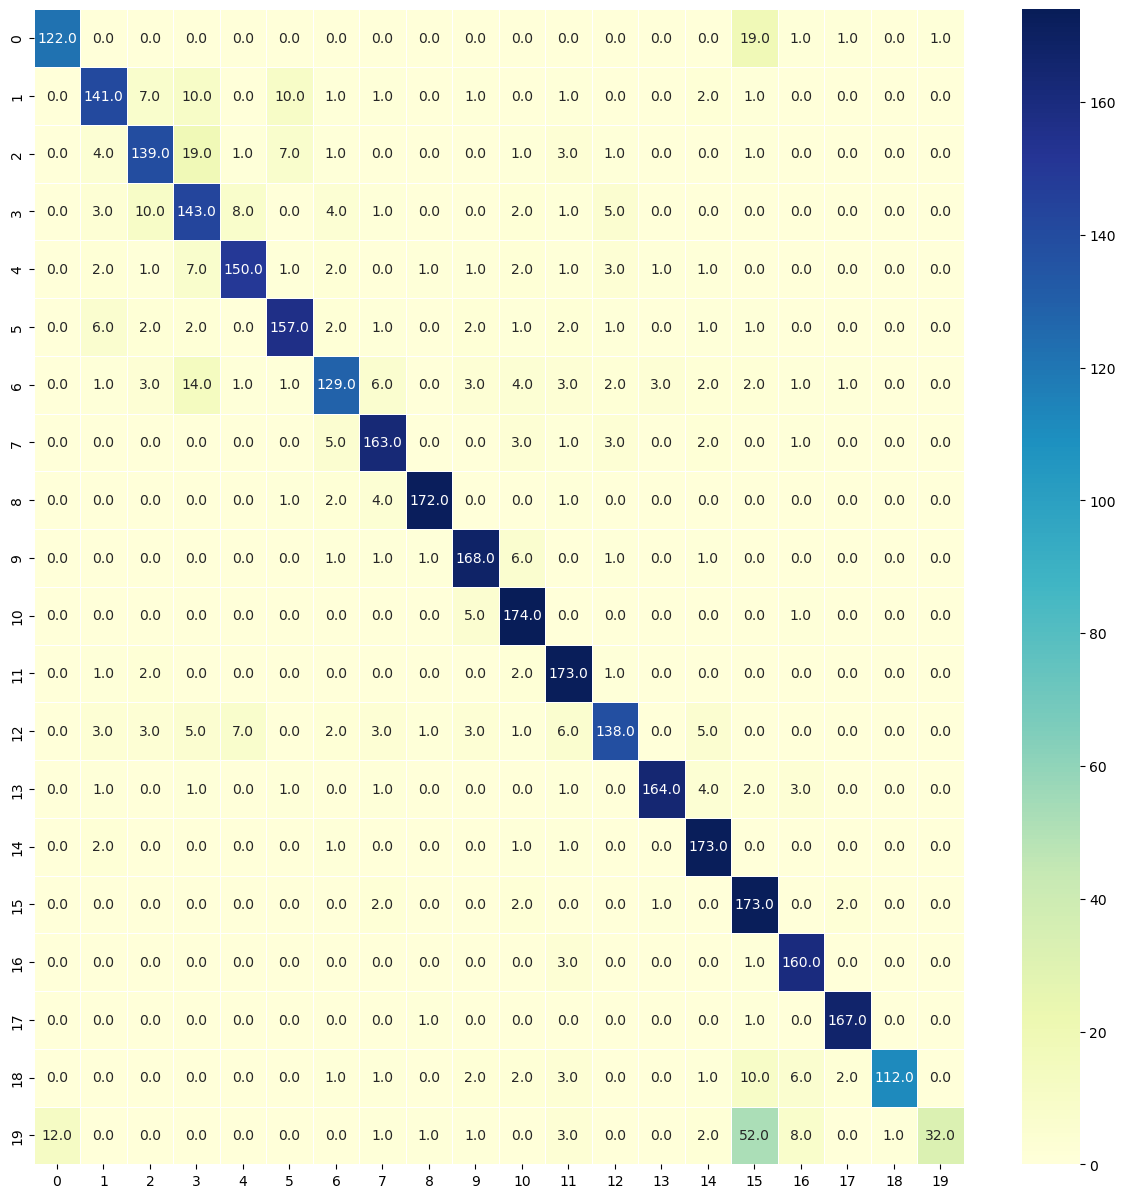


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88       144
           1       0.86      0.81      0.83       175
           2       0.83      0.79      0.81       177
           3       0.71      0.81      0.76       177
           4       0.90      0.87      0.88       173
           5       0.88      0.88      0.88       178
           6       0.85      0.73      0.79       176
           7       0.88      0.92      0.90       178
           8       0.97      0.96      0.96       180
           9       0.90      0.94      0.92       179
          10       0.87      0.97      0.91       180
          11       0.85      0.97      0.91       179
          12       0.89      0.78      0.83       177
          13       0.97      0.92      0.95       178
          14       0.89      0.97      0.93       178
          15       0.66      0.96      0.78       180
          16       0.88      0.98      0.93       164
  

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cm_data =confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
plt.figure(figsize=(15,15))
sns.heatmap(cm_data,cmap='YlGnBu',annot=True,          
    fmt=".1f", 
    linewidths=0.5,        
    linecolor='white')
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [8]:
test_text = [
    "Jesus was born in "
]

test_vector = vectorizer.transform(test_text)
predicted_class = model.predict(test_vector)

print("Predicted Newsgroup:", data["target_names"][predicted_class[0]])

Predicted Newsgroup: comp.graphics
